# simclr_baseline

**Self-Supervised**  
CIFAR-10 → 兩次資料增強 → ResNet-18 → Projector → NT-Xent → kNN → Linear Probe  


## step1:CIFAR10+Augmentation 兩次 → DataLoader → Batch

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# CIFAR-10 normalization
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


class SimCLRTransform:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(
                size=32,
                scale=(0.2, 1.0)
            ),
            transforms.RandomHorizontalFlip(),

            transforms.RandomApply([
                transforms.ColorJitter(
                    brightness=0.4,
                    contrast=0.4,
                    saturation=0.4,
                    hue=0.1
                )
            ], p=0.8),

            transforms.RandomGrayscale(p=0.2),

            transforms.ToTensor(),

            transforms.Normalize(
                CIFAR10_MEAN,
                CIFAR10_STD
            )
        ])

    def __call__(self, image):
        view1 = self.transform(image)
        view2 = self.transform(image)

        return view1, view2


# Dataset
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=SimCLRTransform()
)


# 先用 256
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=True
)


# Test
(view1, view2), labels = next(iter(train_loader))

print("View 1 shape:", view1.shape)
print("View 2 shape:", view2.shape)
print("Labels shape:", labels.shape)
print("Batch size:", batch_size)
print("Effective SimCLR samples:", batch_size * 2)

100.0%
c:\Users\user\anaconda3\envs\summer\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


View 1 shape: torch.Size([256, 3, 32, 32])
View 2 shape: torch.Size([256, 3, 32, 32])
Labels shape: torch.Size([256])
Batch size: 256
Effective SimCLR samples: 512


## step2:Modified ResNet-18 + Projector Head

Projector 主要拿來算 SimCLR 的 contrastive loss；訓練結束後把它丟掉，只留下 Backbone。

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18，禁止 pretrained weights
        self.backbone = resnet18(weights=None)

        # CIFAR-10 是 32x32，所以修改第一層 convolution
        self.backbone.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # 移除原本的 max pooling
        self.backbone.maxpool = nn.Identity()

        # 移除最後 classification layer
        self.backbone.fc = nn.Identity()

        # Projector Head: 512 -> 512 -> 128
        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        h = self.backbone(x)     # Representation: 512
        z = self.projector(h)    # Projection: 128

        return h, z

In [ ]:
# 確定使用 GPU 或 CPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimCLRModel().to(device)

# 拿剛才的一個 batch 測試
x = view1.to(device)

with torch.no_grad():
    h, z = model(x)

print("Device:", device)
print("Input:", x.shape)
print("Backbone output:", h.shape)
print("Projector output:", z.shape)

Device: cuda
Input: torch.Size([256, 3, 32, 32])
Backbone output: torch.Size([256, 512])
Projector output: torch.Size([256, 128])


## step3:NT-Xent Loss

In [4]:
import torch.nn.functional as F


def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent loss for SimCLR.

    z1, z2:
        projector outputs from two augmented views
        shape = [N, 128]
    """

    N = z1.size(0)

    # 合併兩組 augmented views
    # [N, 128] + [N, 128] -> [2N, 128]
    z = torch.cat([z1, z2], dim=0)

    # Normalize，之後 dot product 就等於 cosine similarity
    z = F.normalize(z, dim=1)

    # Pairwise cosine similarity
    # [2N, 128] @ [128, 2N] -> [2N, 2N]
    similarity = torch.matmul(z, z.T) / temperature

    # 排除自己和自己的 similarity
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    similarity.masked_fill_(mask, -float("inf"))

    # Positive pair:
    # 0 <-> N
    # 1 <-> N+1
    # ...
    labels = torch.arange(2 * N, device=z.device)
    labels = (labels + N) % (2 * N)

    # Cross entropy = NT-Xent
    loss = F.cross_entropy(similarity, labels)

    return loss

In [5]:
model.eval()

x1 = view1.to(device)
x2 = view2.to(device)

with torch.no_grad():
    _, z1 = model(x1)
    _, z2 = model(x2)

    loss = nt_xent_loss(z1, z2, temperature=0.5)

print("z1:", z1.shape)
print("z2:", z2.shape)
print("NT-Xent Loss:", loss.item())

z1: torch.Size([256, 128])
z2: torch.Size([256, 128])
NT-Xent Loss: 6.213659286499023


## step4:training loop

In [6]:
import time
import torch.optim as optim

# Baseline optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-6
)

model.train()

total_loss = 0.0
start_time = time.time()

for batch_idx, ((x1, x2), _) in enumerate(train_loader):

    x1 = x1.to(device)
    x2 = x2.to(device)

    # 清除上一個 batch 的 gradient
    optimizer.zero_grad()

    # Forward
    _, z1 = model(x1)
    _, z2 = model(x2)

    # NT-Xent
    loss = nt_xent_loss(
        z1,
        z2,
        temperature=0.5
    )

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    total_loss += loss.item()

    # 每 20 batches 顯示一次
    if (batch_idx + 1) % 20 == 0:
        print(
            f"Batch {batch_idx + 1}/{len(train_loader)} "
            f"| Loss: {loss.item():.4f}"
        )

avg_loss = total_loss / len(train_loader)
elapsed = time.time() - start_time

print("\n===== Epoch finished =====")
print(f"Average Loss: {avg_loss:.4f}")
print(f"Time: {elapsed:.1f} seconds")
print(f"Time: {elapsed/60:.2f} minutes")

Batch 20/195 | Loss: 5.4756
Batch 40/195 | Loss: 5.3498
Batch 60/195 | Loss: 5.3132
Batch 80/195 | Loss: 5.2165
Batch 100/195 | Loss: 5.1603
Batch 120/195 | Loss: 5.1418
Batch 140/195 | Loss: 5.1531
Batch 160/195 | Loss: 5.0909
Batch 180/195 | Loss: 5.1150

===== Epoch finished =====
Average Loss: 5.2607
Time: 76.7 seconds
Time: 1.28 minutes


## step5:kNN Monitor

評估 representation:kNN accuracy 越高 → Backbone 學到的特徵越能把同類圖片聚在一起

In [7]:
# Normal transform for kNN evaluation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

# Training set for building kNN feature bank
knn_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=eval_transform
)

# Test set for kNN evaluation
knn_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=eval_transform
)

knn_train_loader = DataLoader(
    knn_train_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

knn_test_loader = DataLoader(
    knn_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("kNN train:", len(knn_train_dataset))
print("kNN test:", len(knn_test_dataset))

kNN train: 50000
kNN test: 10000


## step6:kNN monitor function

In [8]:
@torch.no_grad()
def knn_monitor(model, train_loader, test_loader, device, k=20):
    model.eval()

    # 1. 建立 training feature bank
    feature_bank = []
    label_bank = []

    for images, labels in train_loader:
        images = images.to(device)

        h, _ = model(images)           # 只用 backbone output
        h = F.normalize(h, dim=1)

        feature_bank.append(h)
        label_bank.append(labels)

    feature_bank = torch.cat(feature_bank, dim=0)
    label_bank = torch.cat(label_bank, dim=0).to(device)

    correct = 0
    total = 0

    # 2. 對 test set 做 kNN
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        h, _ = model(images)
        h = F.normalize(h, dim=1)

        # cosine similarity
        similarity = torch.mm(h, feature_bank.T)

        # 取 k 個最近鄰
        _, indices = similarity.topk(k=k, dim=1)

        neighbor_labels = label_bank[indices]

        # 多數決
        predictions = torch.mode(
            neighbor_labels,
            dim=1
        ).values

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    accuracy = 100.0 * correct / total

    model.train()

    return accuracy

In [9]:
import time

start = time.time()

knn_acc = knn_monitor(
    model,
    knn_train_loader,
    knn_test_loader,
    device,
    k=20
)

elapsed = time.time() - start

print(f"kNN Accuracy: {knn_acc:.2f}%")
print(f"kNN monitor time: {elapsed:.1f} seconds")

kNN Accuracy: 45.34%
kNN monitor time: 9.5 seconds


## step7:正式實驗

In [10]:
import time
import torch
import torch.optim as optim

# =========================
# Baseline settings
# =========================
num_epochs = 200
temperature = 0.5
learning_rate = 3e-4
weight_decay = 1e-6
knn_interval = 5
k = 20

# =========================
# IMPORTANT:
# 建立全新的 model，正式從頭訓練
# =========================
model = SimCLRModel().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# 儲存結果
loss_history = []
knn_epochs = []
knn_history = []

training_start = time.time()

for epoch in range(1, num_epochs + 1):

    # =========================
    # SSL Training
    # =========================
    model.train()

    total_loss = 0.0
    epoch_start = time.time()

    for (x1, x2), _ in train_loader:

        x1 = x1.to(device)
        x2 = x2.to(device)

        optimizer.zero_grad()

        _, z1 = model(x1)
        _, z2 = model(x2)

        loss = nt_xent_loss(
            z1,
            z2,
            temperature=temperature
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch:3d}/{num_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| Time: {epoch_time:.1f}s",
        end=""
    )

    # =========================
    # kNN Monitor every 5 epochs
    # =========================
    if epoch % knn_interval == 0:

        knn_start = time.time()

        knn_acc = knn_monitor(
            model,
            knn_train_loader,
            knn_test_loader,
            device,
            k=k
        )

        knn_time = time.time() - knn_start

        knn_epochs.append(epoch)
        knn_history.append(knn_acc)

        print(
            f" | kNN Accuracy: {knn_acc:.2f}% "
            f"| kNN Time: {knn_time:.1f}s"
        )

        # 每 5 epochs 存 checkpoint
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_history": loss_history,
                "knn_epochs": knn_epochs,
                "knn_history": knn_history,
            },
            "simclr_baseline_checkpoint.pth"
        )

    else:
        print()

# =========================
# Final save
# =========================
torch.save(
    model.state_dict(),
    "simclr_baseline_final.pth"
)

total_time = time.time() - training_start

print("\n===== Training Finished =====")
print(f"Total training time: {total_time / 3600:.2f} hours")
print(f"Final Loss: {loss_history[-1]:.4f}")
print(f"Final kNN Accuracy: {knn_history[-1]:.2f}%")

Epoch [  1/200] | Loss: 5.2717 | Time: 76.9s
Epoch [  2/200] | Loss: 5.0258 | Time: 76.0s
Epoch [  3/200] | Loss: 4.9344 | Time: 75.5s
Epoch [  4/200] | Loss: 4.8798 | Time: 75.6s
Epoch [  5/200] | Loss: 4.8405 | Time: 75.7s | kNN Accuracy: 56.70% | kNN Time: 9.2s
Epoch [  6/200] | Loss: 4.8089 | Time: 75.6s
Epoch [  7/200] | Loss: 4.7871 | Time: 75.7s
Epoch [  8/200] | Loss: 4.7710 | Time: 76.0s
Epoch [  9/200] | Loss: 4.7536 | Time: 75.2s
Epoch [ 10/200] | Loss: 4.7382 | Time: 75.3s | kNN Accuracy: 63.43% | kNN Time: 9.3s
Epoch [ 11/200] | Loss: 4.7302 | Time: 75.6s
Epoch [ 12/200] | Loss: 4.7162 | Time: 81.2s
Epoch [ 13/200] | Loss: 4.7117 | Time: 81.5s
Epoch [ 14/200] | Loss: 4.7050 | Time: 83.1s
Epoch [ 15/200] | Loss: 4.6948 | Time: 82.5s | kNN Accuracy: 68.16% | kNN Time: 10.0s
Epoch [ 16/200] | Loss: 4.6876 | Time: 90.1s
Epoch [ 17/200] | Loss: 4.6846 | Time: 89.8s
Epoch [ 18/200] | Loss: 4.6772 | Time: 87.1s
Epoch [ 19/200] | Loss: 4.6743 | Time: 85.3s
Epoch [ 20/200] | Loss: 

## step8:畫圖

In [12]:
pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------- ------------------- 4.7/9.3 MB 35.7 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 48.4 MB/s  0:00:00
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
 

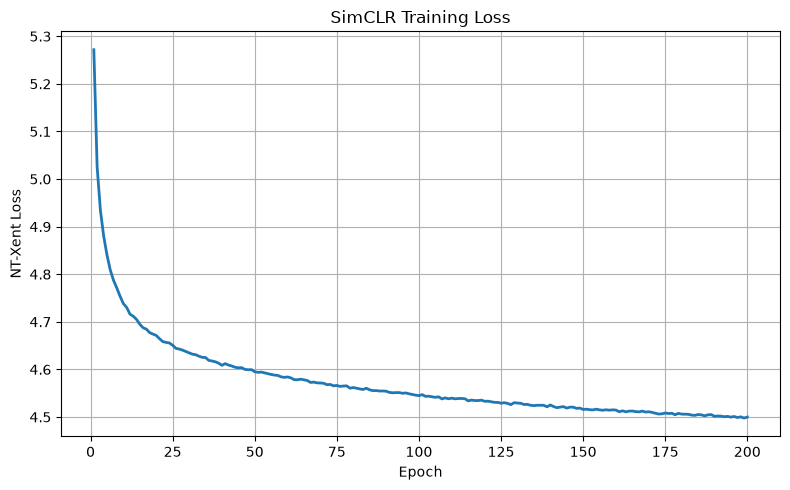

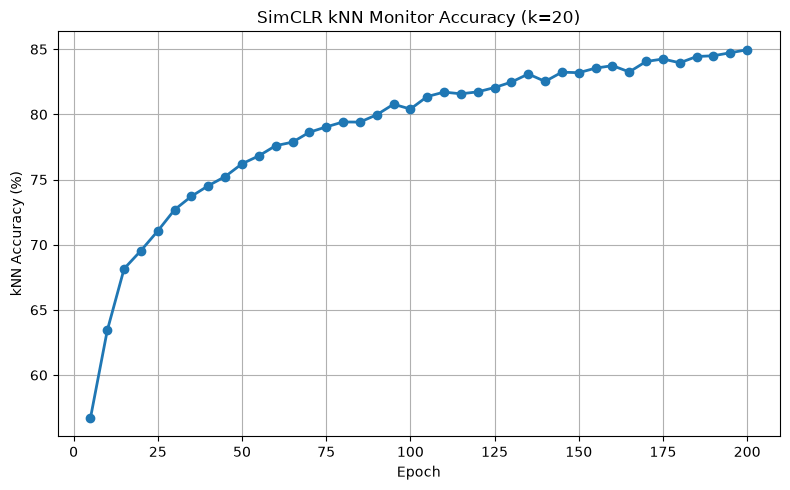

In [13]:
import matplotlib.pyplot as plt

# =========================
# 1. SSL Training Loss Curve
# =========================
epochs = range(1, len(loss_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_history, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("SimCLR Training Loss")
plt.grid(True)

plt.tight_layout()
plt.savefig("simclr_loss_curve.png", dpi=300)
plt.show()


# =========================
# 2. kNN Monitor Accuracy Curve
# =========================
plt.figure(figsize=(8, 5))
plt.plot(
    knn_epochs,
    knn_history,
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("kNN Accuracy (%)")
plt.title("SimCLR kNN Monitor Accuracy (k=20)")
plt.grid(True)

plt.tight_layout()
plt.savefig("simclr_knn_accuracy_curve.png", dpi=300)
plt.show()

In [15]:
pip install pandas

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.0 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/10.0 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/10.0 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/10.0 MB 4.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/10.0 MB 5.3 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/10.0 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 6.9 MB/s  0:00:01

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- -------------

In [16]:
import pandas as pd

# Loss data
loss_df = pd.DataFrame({
    "Epoch": list(range(1, len(loss_history) + 1)),
    "Loss": loss_history
})

loss_df.to_csv(
    "simclr_loss_history.csv",
    index=False
)

# kNN data
knn_df = pd.DataFrame({
    "Epoch": knn_epochs,
    "kNN_Accuracy": knn_history
})

knn_df.to_csv(
    "simclr_knn_history.csv",
    index=False
)

print("Results saved.")

Results saved.


## step9:Linear Probing

Backbone 完全 freeze，只訓練一個非常簡單的 Linear classifier。如果這麼簡單的分類器就能得到高 accuracy，表示 Backbone 原本學到的 representation 已經很好分。

### (1)準備 Linear Probing Dataset

In [17]:
# Linear probing transform
linear_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

linear_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=linear_transform
)

linear_test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=linear_transform
)

linear_train_loader = DataLoader(
    linear_train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

linear_test_loader = DataLoader(
    linear_test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

print("Train:", len(linear_train_dataset))
print("Test:", len(linear_test_dataset))

c:\Users\user\anaconda3\envs\summer\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000
Test: 10000


### (2)Freeze 已訓練好的 Backbone

In [18]:
# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# 確認 backbone 不會被更新
model.backbone.eval()

print("Backbone frozen.")
print(
    "Trainable backbone parameters:",
    sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
)

Backbone frozen.
Trainable backbone parameters: 0


### (3)建立 Linear Classifier

In [19]:
linear_classifier = nn.Linear(512, 10).to(device)

criterion = nn.CrossEntropyLoss()

linear_optimizer = optim.Adam(
    linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-6
)

print(linear_classifier)

Linear(in_features=512, out_features=10, bias=True)


### (4)Linear Probing 100 Epochs

In [20]:
import time

linear_epochs = 100

linear_train_loss = []
linear_test_accuracy = []

start_time = time.time()

for epoch in range(1, linear_epochs + 1):

    # =========================
    # Train linear classifier
    # =========================
    linear_classifier.train()
    model.backbone.eval()

    total_loss = 0.0

    for images, labels in linear_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        linear_optimizer.zero_grad()

        # Backbone 完全不計算 gradient
        with torch.no_grad():
            features = model.backbone(images)

        logits = linear_classifier(features)

        loss = criterion(logits, labels)

        loss.backward()
        linear_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(linear_train_loader)
    linear_train_loss.append(avg_loss)

    # =========================
    # Test
    # =========================
    linear_classifier.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in linear_test_loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model.backbone(images)
            logits = linear_classifier(features)

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    test_acc = 100.0 * correct / total
    linear_test_accuracy.append(test_acc)

    print(
        f"Epoch [{epoch:3d}/{linear_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| Test Accuracy: {test_acc:.2f}%"
    )


elapsed = time.time() - start_time

print("\n===== Linear Probing Finished =====")
print(f"Training time: {elapsed/60:.2f} minutes")
print(f"Final Test Accuracy: {linear_test_accuracy[-1]:.2f}%")
print(f"Best Test Accuracy: {max(linear_test_accuracy):.2f}%")

Epoch [  1/100] | Loss: 0.6180 | Test Accuracy: 84.23%
Epoch [  2/100] | Loss: 0.4177 | Test Accuracy: 84.86%
Epoch [  3/100] | Loss: 0.3940 | Test Accuracy: 85.16%
Epoch [  4/100] | Loss: 0.3823 | Test Accuracy: 85.26%
Epoch [  5/100] | Loss: 0.3750 | Test Accuracy: 85.43%
Epoch [  6/100] | Loss: 0.3691 | Test Accuracy: 85.45%
Epoch [  7/100] | Loss: 0.3631 | Test Accuracy: 85.68%
Epoch [  8/100] | Loss: 0.3600 | Test Accuracy: 85.88%
Epoch [  9/100] | Loss: 0.3562 | Test Accuracy: 86.04%
Epoch [ 10/100] | Loss: 0.3543 | Test Accuracy: 85.86%
Epoch [ 11/100] | Loss: 0.3507 | Test Accuracy: 86.26%
Epoch [ 12/100] | Loss: 0.3468 | Test Accuracy: 86.27%
Epoch [ 13/100] | Loss: 0.3455 | Test Accuracy: 86.37%
Epoch [ 14/100] | Loss: 0.3429 | Test Accuracy: 86.31%
Epoch [ 15/100] | Loss: 0.3413 | Test Accuracy: 86.68%
Epoch [ 16/100] | Loss: 0.3397 | Test Accuracy: 86.49%
Epoch [ 17/100] | Loss: 0.3367 | Test Accuracy: 86.67%
Epoch [ 18/100] | Loss: 0.3358 | Test Accuracy: 85.85%
Epoch [ 19